# M2S14 — Data Visualization: Full Answer
## HR Employee Attrition Analysis
---
**Program** : Job Connector Data Science & Machine Learning  
**Dataset** : IBM HR Employee Attrition  
**Note**    : Notebook ini adalah **referensi jawaban** — bukan satu-satunya pendekatan yang benar.
              Grafik dapat bervariasi selama prinsip data storytelling terpenuhi.


---
## A. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120


In [2]:
df = pd.read_csv('HR-Employee-Attrition.csv')
print(f'Shape  : {df.shape}')
print(f'Missing: {df.isnull().sum().sum()}')
df.head()


Shape  : (1470, 35)
Missing: 0


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


---
## B. Data Cleaning

In [3]:
# Step 1 — Drop kolom konstan
cols_to_drop = ['EmployeeCount', 'StandardHours', 'Over18']
df = df.drop(columns=cols_to_drop)
print(f'Shape setelah drop: {df.shape}')


Shape setelah drop: (1470, 32)


In [4]:
# Step 2 — Konversi tipe data
df['Attrition_bin'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime_bin']  = df['OverTime'].map({'Yes': 1, 'No': 0})


In [5]:
# Step 3 — Label encoding ordinal
sat_map = {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'}
df['JobSatisfaction_label'] = df['JobSatisfaction'].map(sat_map)
df['WorkLifeBalance_label'] = df['WorkLifeBalance'].map(sat_map)
df['EnvSatisfaction_label'] = df['EnvironmentSatisfaction'].map(sat_map)
df['RelSatisfaction_label'] = df['RelationshipSatisfaction'].map(sat_map)

edu_map = {1: 'Below College', 2: 'College', 3: 'Bachelor', 4: 'Master', 5: 'Doctor'}
df['Education_label'] = df['Education'].map(edu_map)

# Step 4 — Distance bins (dipakai di No.12)
df['dist_group'] = pd.cut(df['DistanceFromHome'],
                          bins=[0, 10, 20, 29],
                          labels=['Near (1–10 km)', 'Medium (11–20 km)', 'Far (21–29 km)'])

print(f'Shape final    : {df.shape}')
print(f'Attrition rate : {df["Attrition_bin"].mean()*100:.1f}%')


Shape final    : (1470, 40)
Attrition rate : 16.1%


---
## C. Latihan Visualisasi

---
### No. 1 — Distribusi Usia Karyawan
**Chart Type:** Histogram &nbsp;|&nbsp; **Level:** 🟢 Starter Code


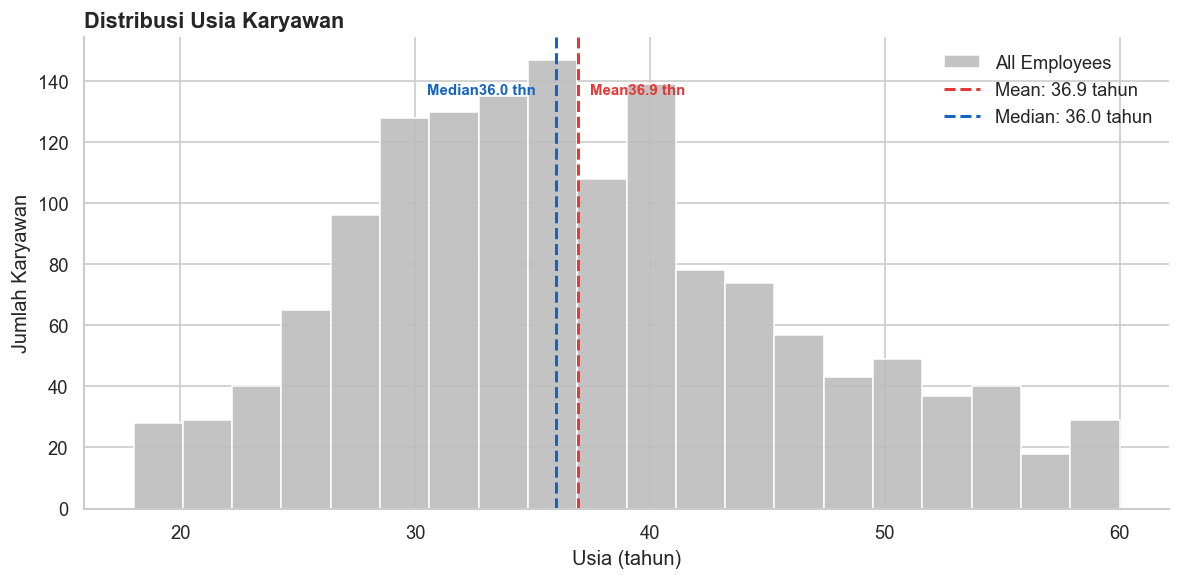

In [6]:
# ── Blok 1: Distribusi usia keseluruhan ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Base histogram — warna netral (declutter: single color, no grid overload)
ax.hist(df['Age'], bins=20, color='#BDBDBD', edgecolor='white', alpha=0.9, label='All Employees')

# Context lines — mean & median sebagai referensi
ax.axvline(df['Age'].mean(),   color='#E53935', linestyle='--', linewidth=1.8,
           label=f"Mean: {df['Age'].mean():.1f} tahun")
ax.axvline(df['Age'].median(), color='#1565C0', linestyle='--', linewidth=1.8,
           label=f"Median: {df['Age'].median():.1f} tahun")

# Annotation langsung di chart (storytelling: tidak hanya mengandalkan legend)
ax.text(df['Age'].mean() + 0.5, ax.get_ylim()[1] * 0.88,f"Mean{df['Age'].mean():.1f} thn", color='#E53935', fontsize=9, fontweight='bold')
ax.text(df['Age'].median() - 5.5, ax.get_ylim()[1] * 0.88,
        f"Median{df['Age'].median():.1f} thn", color='#1565C0', fontsize=9, fontweight='bold')

# Declutter — hapus top & right spine
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title('Distribusi Usia Karyawan', fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Usia (tahun)')
ax.set_ylabel('Jumlah Karyawan')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


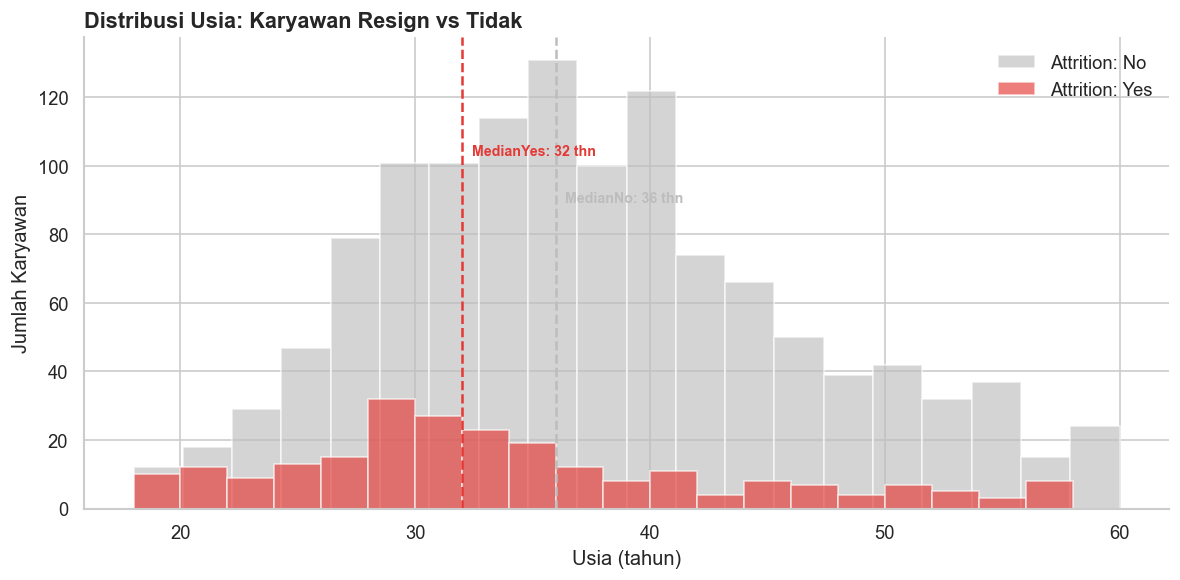

In [7]:
# ── Blok 2: Overlay distribusi usia per Attrition group ─────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Highlight: Attrition=Yes diberi warna aksen (tomato), No diberi warna abu-abu
colors = {'No': '#BDBDBD', 'Yes': '#E53935'}
for attr_val, color in colors.items():
    subset = df[df['Attrition'] == attr_val]['Age']
    ax.hist(subset, bins=20, alpha=0.65, color=color,
            edgecolor='white', label=f'Attrition: {attr_val}')

# Context line — median per group
for attr_val, color in colors.items():
    med = df[df['Attrition'] == attr_val]['Age'].median()
    ax.axvline(med, color=color, linestyle='--', linewidth=1.5)
    ax.text(med + 0.4, ax.get_ylim()[1] * 0.75 if attr_val == 'Yes' else ax.get_ylim()[1] * 0.65,
            f'Median{attr_val}: {med:.0f} thn',
            color=color, fontsize=8.5, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Distribusi Usia: Karyawan Resign vs Tidak', fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Usia (tahun)')
ax.set_ylabel('Jumlah Karyawan')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


#### 💡 Insight No. 1

| | |
|---|---|
| 📊 **Observasi** | distibusi usia karyawan menunjukkan bahwa relatif mendekati normal dengan mean 36,9 dan median 36, dan usia terkonsentrasi pada rentang 30 sampai dengan 40 tahun. Karyawan yang resign memiliki median usia 33.6 tahun, lebih muda 4 tahun dibanding yang bertahan (median 37.6 thn). Sebesar 38.4% karyawan yang resign berusia di bawah 30 tahun. |
| 🔍 **Interpretasi** | Attrition terkonsentrasi pada karyawan muda yang kemungkinan besar berada di tahap awal karier (*early-career employees*). Kelompok ini cenderung lebih mobile, memiliki *switching cost* yang rendah, dan lebih berorientasi pada pertumbuhan karier dibanding stabilitas. Pola ini umum di industri teknologi dan riset, di mana talenta muda sangat kompetitif di pasar tenaga kerja. |
| 📌 **Rekomendasi** | **Dalam 6 bulan ke depan**, rancang program *early-career retention* yang spesifik: (1) implementasi *structured career path* yang transparan untuk karyawan usia < 30 tahun, (2) buat program *mentoring* yang menghubungkan karyawan junior dengan senior di department yang sama. **Target terukur**: turunkan attrition rate karyawan usia < 30 dari 38.4% menjadi ≤ 25% dalam 1 tahun. **Dampak estimasi**: jika 30% dari 91 karyawan < 30 tahun yang berpotensi resign dapat dipertahankan, perusahaan menghemat biaya rekrutmen ±27 headcount × rata-rata 50% gaji tahunan per hire. |

---
### No. 2 — Gaji Karyawan Lembur vs Tidak Lembur
**Chart Type:** Boxplot &nbsp;|&nbsp; **Level:** 🟢 Starter Code


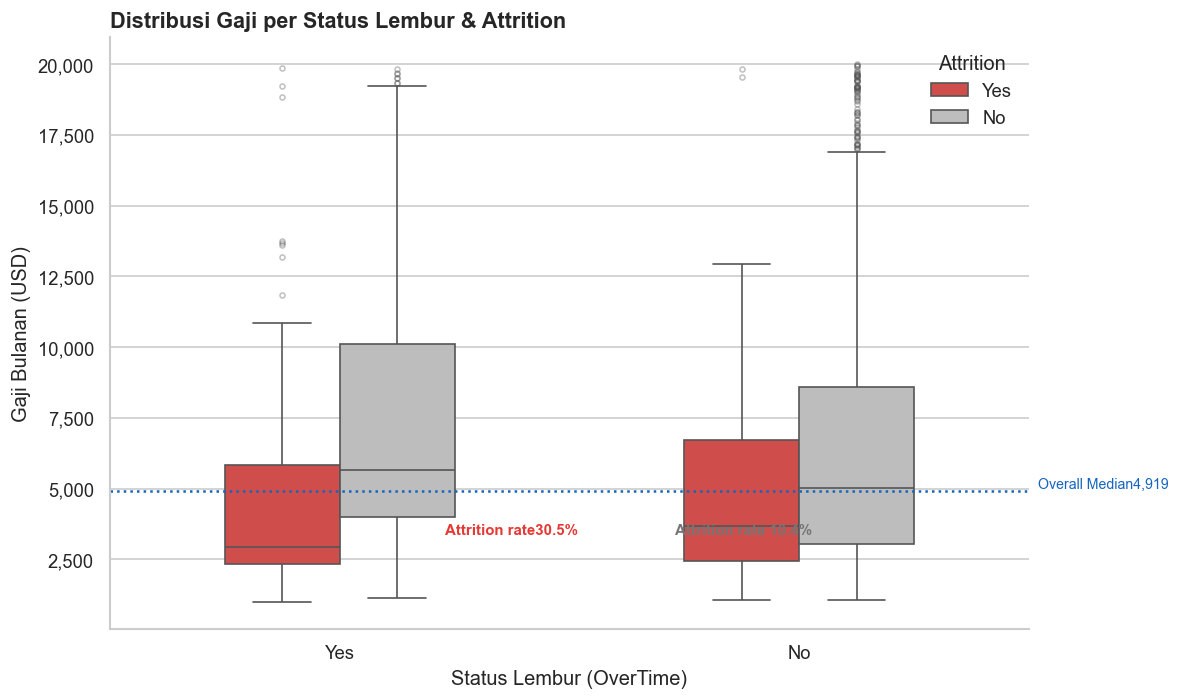

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

# Highlight: Yes = aksen merah, No = abu-abu
palette = {'No': '#BDBDBD', 'Yes': '#E53935'}

sns.boxplot(
    data=df, x='OverTime', y='MonthlyIncome', hue='Attrition',
    palette=palette, width=0.5,
    flierprops=dict(marker='o', markersize=3, alpha=0.35),
    ax=ax
)

# Context line — median keseluruhan sebagai benchmark
overall_median = df['MonthlyIncome'].median()
ax.axhline(overall_median, color='#1565C0', linestyle=':', linewidth=1.5)
ax.text(1.52, overall_median * 1.02,
        f'Overall Median{overall_median:,.0f}', color='#1565C0', fontsize=8.5)

# Annotation attrition rate per group (storytelling: angka penting langsung terlihat)
ax.annotate(f'Attrition rate30.5%', xy=(0.23, 3400), fontsize=9,
            color='#E53935', fontweight='bold')
ax.annotate(f'Attrition rate 10.4%', xy=(0.73, 3400), fontsize=9,
            color='#757575', fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Distribusi Gaji per Status Lembur & Attrition', fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Status Lembur (OverTime)')
ax.set_ylabel('Gaji Bulanan (USD)')
ax.legend(title='Attrition', frameon=False)
plt.tight_layout()
plt.show()


#### 💡 Insight No. 2

| | |
|---|---|
| 📊 **Observasi** | Karyawan yang lembur (OverTime=Yes) memiliki **attrition rate 30.5%** — hampir 3× lipat dibanding yang tidak lembur (10.4%). Menariknya, median gaji karyawan yang lembur (USD 5,061) justru **sedikit lebih tinggi** dari yang tidak lembur (USD 4,880). Karyawan yang resign dan lembur memiliki gaji median paling rendah (~USD 3,200), jauh di bawah overall median USD 4,919. |
| 🔍 **Interpretasi** | Temuan ini menunjukkan bahwa **karyawan tidak resign karena dibayar rendah akibat lembur**, melainkan karena *workload* dan tekanan pekerjaan yang tidak sebanding dengan kompensasi. Karyawan yang resign + lembur adalah kelompok paling "terbakar habis" (*burnt out*): mereka bekerja lebih keras namun tetap dibayar di bawah rata-rata. Ini adalah sinyal *work-life balance* yang serius, bukan sekadar masalah kompensasi. |
| 📌 **Rekomendasi** | **Dalam 3 bulan ke depan**: (1) Lakukan audit *workload* pada semua karyawan berstatus OverTime — identifikasi apakah lembur disebabkan understaffing atau inefisiensi proses. (2) Terapkan kebijakan *overtime cap*: maksimal 10 jam/minggu dengan kompensasi insentif. **Target terukur**: turunkan attrition rate kelompok OverTime dari 30.5% mendekati 15% dalam 12 bulan. **Dampak**: dari 271 karyawan yang saat ini lembur, potensi resign ~83 orang — setiap 20 orang yang berhasil diretain menghemat biaya rekrutmen setara 10–12 bulan gaji. |


---
### No. 3 — Tren Rata-rata Gaji berdasarkan Lama Bekerja
**Chart Type:** Line Chart &nbsp;|&nbsp; **Level:** 🟢 Starter Code


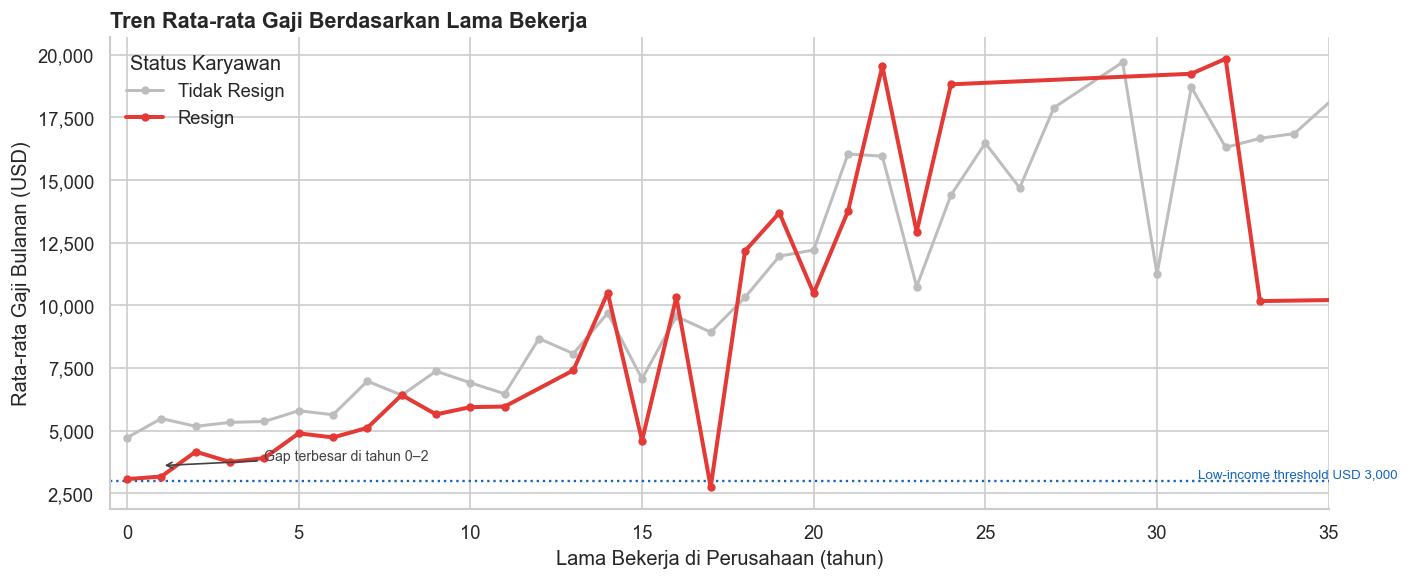

In [9]:
trend = (
    df.groupby(['YearsAtCompany', 'Attrition'])['MonthlyIncome']
    .mean().reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

# Highlight: Yes = aksen merah tebal, No = abu-abu tipis
styles = {'No': ('#BDBDBD', 1.8, 'Tidak Resign'), 'Yes': ('#E53935', 2.4, 'Resign')}
for group, (color, lw, label) in styles.items():
    subset = trend[trend['Attrition'] == group]
    ax.plot(subset['YearsAtCompany'], subset['MonthlyIncome'],
            marker='o', markersize=4, color=color, linewidth=lw, label=label, zorder=3)

# Context line — gaji entry level benchmark (UMR proxy)
ax.axhline(3000, color='#1565C0', linestyle=':', linewidth=1.4)
ax.text(31.2, 3100, 'Low-income threshold USD 3,000', color='#1565C0', fontsize=8)

# Annotation — gap paling signifikan di tahun awal
ax.annotate('Gap terbesar di tahun 0–2',
            xy=(1, 3600), xytext=(4, 3800),
            arrowprops=dict(arrowstyle='->', color='#424242'),
            fontsize=8.5, color='#424242')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Tren Rata-rata Gaji Berdasarkan Lama Bekerja', fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Lama Bekerja di Perusahaan (tahun)')
ax.set_ylabel('Rata-rata Gaji Bulanan (USD)')
ax.set_xlim(-0.5, 35)
ax.legend(title='Status Karyawan', frameon=False)
plt.tight_layout()
plt.show()


#### 💡 Insight No. 3

| | |
|---|---|
| 📊 **Observasi** | Terdapat **gap gaji yang konsisten** antara karyawan resign dan tidak resign di hampir semua titik masa kerja. Pada tahun ke-0, rata-rata gaji karyawan resign adalah **USD 3,060** vs USD 4,715 untuk yang bertahan — selisih **USD 1,655 (35%)**. Korelasi antara lama bekerja dan gaji cukup kuat (r = 0.514). Karyawan yang resign cenderung memiliki lama kerja median **3 tahun** vs 6 tahun untuk yang bertahan. |
| 🔍 **Interpretasi** | Karyawan resign sebelum sempat mencapai level gaji yang kompetitif. Pola ini mengindikasikan adanya **"honeymoon period" yang singkat**: karyawan baru bergabung dengan ekspektasi pertumbuhan gaji, namun jika tidak terpenuhi dalam 2–3 tahun pertama, mereka memilih keluar. Gap sebesar 35% di tahun pertama sangat signifikan dan kemungkinan mencerminkan praktik *underpaying new hires* dibanding pasar. |
| 📌 **Rekomendasi** | **Segera (1–3 bulan)**: lakukan *salary benchmarking* eksternal untuk posisi entry-to-mid level (0–3 tahun pengalaman). Jika ditemukan *underpay* ≥ 15% dibanding pasar, prioritaskan koreksi gaji untuk kelompok ini. **Target terukur**: eliminasi gap gaji pada karyawan masa kerja 0–2 tahun dari 35% menjadi ≤ 10% dalam 6 bulan. **Dampak**: berdasarkan data, 47.7% karyawan yang resign bergaji di bawah USD 3,000 — menaikkan gaji 50 karyawan entry-level sebesar USD 500/bulan menghabiskan USD 300K/tahun, jauh lebih murah dibanding biaya turnover 50 karyawan baru. |


---
### No. 4 — Hubungan Usia dan Gaji Bulanan Karyawan
**Chart Type:** Scatter Plot &nbsp;|&nbsp; **Level:** 🟢 Starter Code


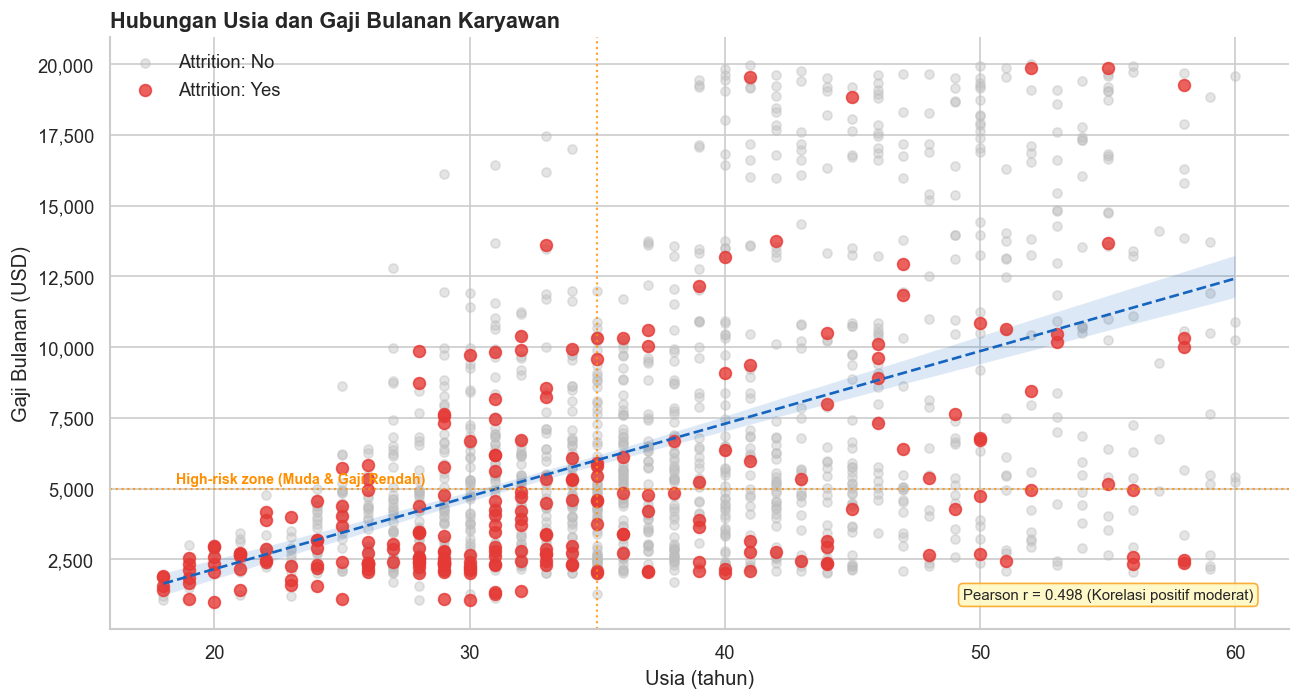

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))

# Highlight: Yes = aksen merah kecil, No = abu-abu besar (agar Yes terlihat jelas)
for attr_val, (color, size, alpha, zorder) in {
    'No':  ('#BDBDBD', 30, 0.4, 1),
    'Yes': ('#E53935', 50, 0.8, 2),
}.items():
    subset = df[df['Attrition'] == attr_val]
    ax.scatter(subset['Age'], subset['MonthlyIncome'],
               color=color, s=size, alpha=alpha, zorder=zorder,
               label=f'Attrition: {attr_val}')

# Regression line — overall trend
sns.regplot(data=df, x='Age', y='MonthlyIncome',
            scatter=False, color='#1565C0',
            line_kws={'linewidth': 1.6, 'linestyle': '--'}, ax=ax)

# Annotation zona risiko tinggi
ax.axvline(35, color='#FF8F00', linestyle=':', linewidth=1.3, alpha=0.8)
ax.axhline(5000, color='#FF8F00', linestyle=':', linewidth=1.3, alpha=0.8)
ax.text(18.5, 5200, 'High-risk zone (Muda & Gaji Rendah)', color='#FF8F00',
        fontsize=8.5, fontweight='bold')

# Pearson r annotation
r = df['Age'].corr(df['MonthlyIncome'])
ax.text(0.97, 0.05, f'Pearson r = {r:.3f} (Korelasi positif moderat)',
        transform=ax.transAxes, ha='right', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#FFF9C4', edgecolor='#F9A825', alpha=0.9))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Hubungan Usia dan Gaji Bulanan Karyawan', fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Usia (tahun)')
ax.set_ylabel('Gaji Bulanan (USD)')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


#### 💡 Insight No. 4

| | |
|---|---|
| 📊 **Observasi** | Terdapat **korelasi positif moderat** antara usia dan gaji (Pearson r = 0.498). Namun, titik merah (resign) sangat terkonsentrasi di **kuadran kiri bawah**: usia < 35 tahun dengan gaji < USD 5,000. Sebanyak **47.7% karyawan yang resign bergaji di bawah USD 3,000**, sementara hanya 22.9% pada kelompok yang bertahan. Terdapat **122 karyawan** berusia < 35 tahun bergaji < USD 5,000 yang resign — ini adalah segmen risiko tertinggi. |
| 🔍 **Interpretasi** | Kombinasi *muda* dan *bergaji rendah* adalah prediktor attrition terkuat. Karyawan di kuadran ini belum cukup "terikat" secara finansial maupun karier dengan perusahaan, sehingga tawaran eksternal dengan selisih gaji kecil pun sudah cukup untuk memicu keputusan resign. Korelasi usia–gaji yang hanya 0.498 juga mengindikasikan bahwa **senioritas tidak selalu diikuti kenaikan gaji**, yang memperburuk persepsi keadilan kompensasi. |
| 📌 **Rekomendasi** | **Prioritas tinggi**: buat segmentasi karyawan berdasarkan kombinasi usia dan gaji. Identifikasi seluruh karyawan di high-risk zone (usia < 35, gaji < USD 5,000) — lakukan *retention interview* dalam 30 hari ke depan. **Target terukur**: berikan *proactive salary adjustment* rata-rata 10–15% untuk 122 karyawan di zona risiko tinggi. **Dampak**: jika 40% dari 122 karyawan tersebut berhasil diretain, perusahaan menghemat biaya penggantian ~49 karyawan, setara penghematan USD 735K–1.2M (asumsi replacement cost = 50–100% annual salary). |


---
### No. 5 — Jumlah Karyawan per Department
**Chart Type:** Bar Chart &nbsp;|&nbsp; **Level:** 🔵 Petunjuk Kolom


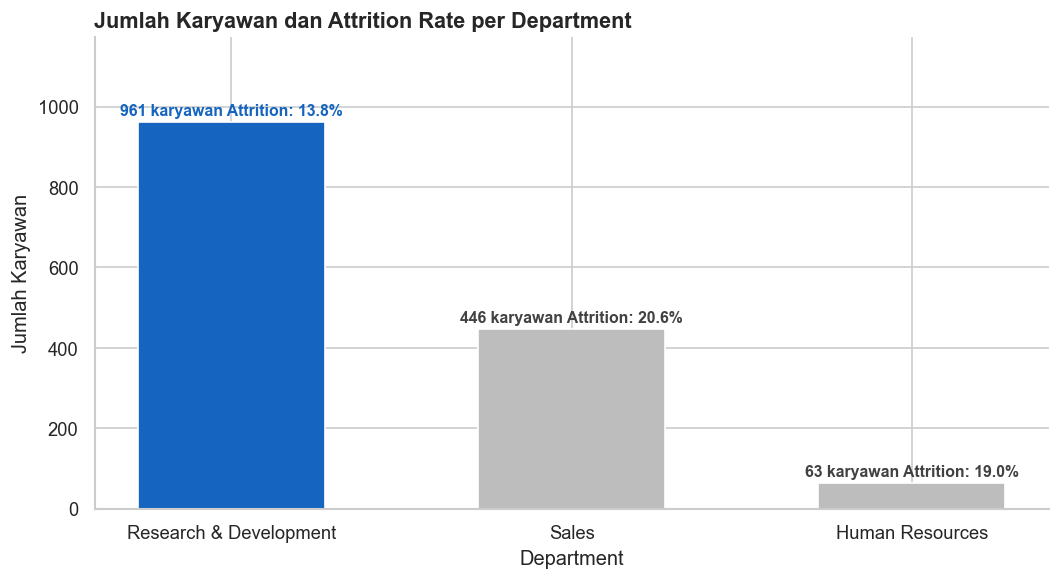

In [11]:
dept_counts = df['Department'].value_counts().sort_values(ascending=False)
dept_attr   = (df.groupby('Department')['Attrition_bin'].mean() * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))

# Highlight: R&D = aksen biru (terbanyak), sisanya abu-abu
colors = ['#1565C0' if d == 'Research & Development' else '#BDBDBD'
          for d in dept_counts.index]

bars = ax.bar(dept_counts.index, dept_counts.values,
              color=colors, edgecolor='white', width=0.55)

# Annotation: count + attrition rate langsung di atas bar
for bar, dept in zip(bars, dept_counts.index):
    h = bar.get_height()
    atr = dept_attr[dept]
    ax.text(bar.get_x() + bar.get_width()/2, h + 10,
            f'{h:,} karyawan Attrition: {atr}%',
            ha='center', va='bottom', fontsize=9.5,
            color='#1565C0' if dept == 'Research & Development' else '#424242',
            fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, dept_counts.max() * 1.22)
ax.set_title('Jumlah Karyawan dan Attrition Rate per Department',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Department')
ax.set_ylabel('Jumlah Karyawan')
plt.tight_layout()
plt.show()


#### 💡 Insight No. 5

| | |
|---|---|
| 📊 **Observasi** | **Research & Development** mendominasi workforce dengan **961 karyawan (65.4%)**, diikuti Sales (446, 30.3%) dan Human Resources (63, 4.3%). Meski R&D terbesar secara absolut, attrition rate-nya **13.8%** masih lebih rendah dari Sales (20.6%) dan HR (19.0%). Sales memiliki attrition rate tertinggi di antara tiga department. |
| 🔍 **Interpretasi** | Tingginya attrition di **Sales (20.6%)** perlu mendapat perhatian lebih karena department ini berhadapan langsung dengan revenue perusahaan. Kehilangan Sales talent berarti kehilangan *relationship* dengan klien dan potensi penurunan performa penjualan. HR dengan attrition 19.0% juga mengkhawatirkan karena departemen ini yang justru bertugas meretain karyawan lain. |
| 📌 **Rekomendasi** | **Prioritas intervensi**: Sales department — lakukan audit kompensasi dan *incentive structure* Sales dalam 60 hari ke depan. Rancang skema komisi yang lebih kompetitif dan transparan. **Target terukur**: turunkan attrition rate Sales dari 20.6% ke ≤ 13% dalam 12 bulan (mendekati level R&D). **Dampak**: Sales memiliki 446 karyawan; penurunan attrition 7.6 poin berarti ~34 karyawan Sales yang berhasil diretain per tahun — mengingat Sales talent memiliki replacement cost tertinggi, ini setara penghematan signifikan dalam pipeline rekrutmen. |


---
### No. 6 — Proporsi Tingkat Pendidikan Karyawan
**Chart Type:** Pie Chart &nbsp;|&nbsp; **Level:** 🔵 Petunjuk Kolom


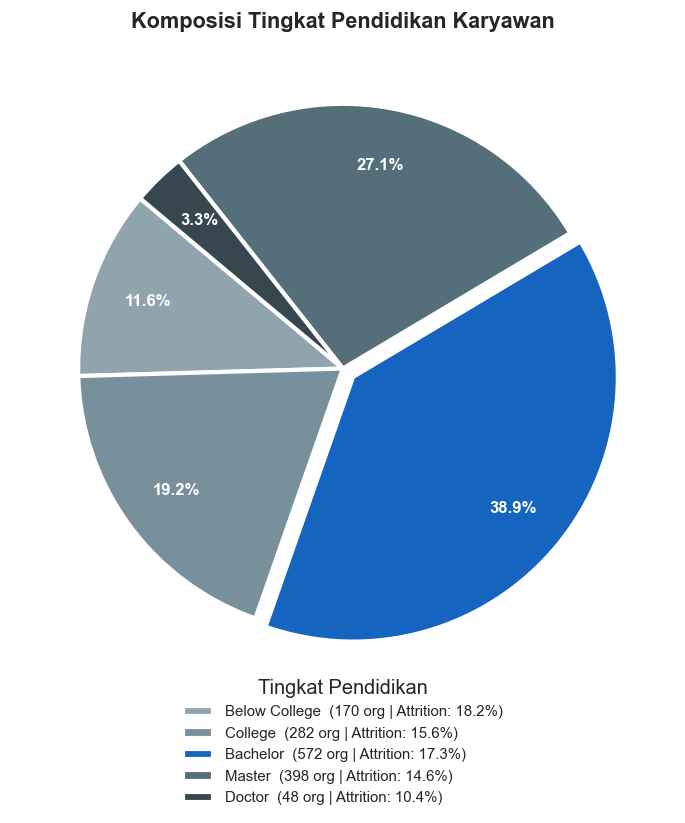

In [12]:
edu_order  = ['Below College', 'College', 'Bachelor', 'Master', 'Doctor']
edu_counts = df['Education_label'].value_counts().reindex(edu_order)

# Highlight: Bachelor = aksen biru (mayoritas), sisanya abu-abu gradient
colors = ['#90A4AE', '#78909C', '#1565C0', '#546E7A', '#37474F']

fig, ax = plt.subplots(figsize=(8, 7))
wedges, texts, autotexts = ax.pie(
    edu_counts,
    labels=None,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    pctdistance=0.78,
    wedgeprops=dict(edgecolor='white', linewidth=2.5),
    explode=[0, 0, 0.05, 0, 0]  # Highlight Bachelor
)

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

# Legend dengan count dan attrition rate
edu_attr = (df.groupby('Education_label')['Attrition_bin'].mean() * 100).reindex(edu_order)
legend_labels = [
    f'{edu}  ({cnt:,} org | Attrition: {edu_attr[edu]:.1f}%)'
    for edu, cnt in zip(edu_order, edu_counts)
]
ax.legend(wedges, legend_labels, title='Tingkat Pendidikan',
          loc='lower center', bbox_to_anchor=(0.5, -0.18),
          ncol=1, fontsize=9, frameon=False)

ax.set_title('Komposisi Tingkat Pendidikan Karyawan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


#### 💡 Insight No. 6

| | |
|---|---|
| 📊 **Observasi** | Karyawan didominasi oleh lulusan **Bachelor (38.9%, 572 orang)**, diikuti Master (27.1%, 398 orang), College (19.2%, 282 orang), Below College (11.6%, 170 orang), dan Doctor (3.3%, 48 orang). Menariknya, attrition rate **berbanding terbalik dengan tingkat pendidikan**: Below College (18.2%) > Bachelor (17.3%) > College (15.6%) > Master (14.6%) > Doctor (10.4%). |
| 🔍 **Interpretasi** | Karyawan dengan pendidikan lebih tinggi (Master, Doctor) memiliki attrition lebih rendah, kemungkinan karena posisi mereka lebih spesifik dan *switching cost* lebih tinggi. Namun, kelompok **Bachelor** yang menjadi mayoritas workforce justru menunjukkan attrition 17.3% — karena kelompok ini paling kompetitif di pasar kerja dan paling banyak mendapat tawaran dari kompetitor. |
| 📌 **Rekomendasi** | **Fokus pada segmen Bachelor**: sebagai kelompok terbesar (572 orang) dengan attrition 17.3%, potensi kehilangan ~99 karyawan/tahun dari segmen ini saja. Rancang **program pengembangan kompetensi berjenjang** yang memberikan jalur jelas dari Bachelor ke level yang setara Master dalam 2–3 tahun (*upskilling pathway*). **Target terukur**: turunkan attrition Bachelor dari 17.3% ke ≤ 12% dalam 18 bulan. **Dampak**: setiap 1 poin penurunan attrition Bachelor = ~5–6 karyawan yang diretain = penghematan biaya rekrutmen dan *onboarding* yang signifikan. |


---
### No. 7 — Distribusi Gaji: Karyawan Resign vs Tidak
**Chart Type:** Histogram &nbsp;|&nbsp; **Level:** 🟣 Mandiri


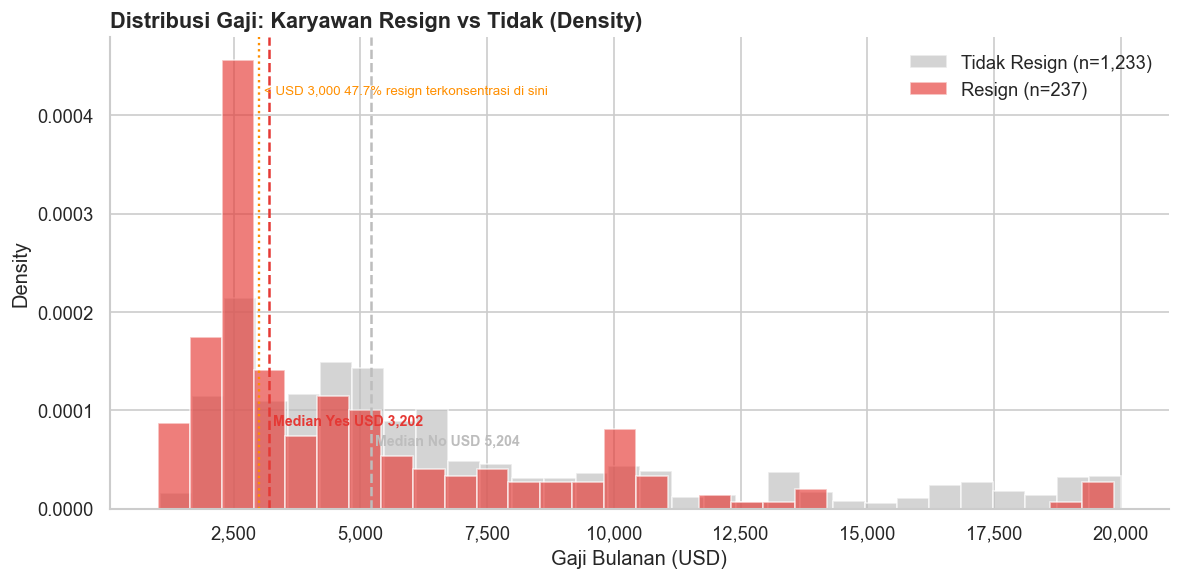

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

# density=True agar proporsional (jumlah sampel tidak seimbang)
for attr_val, (color, label) in {
    'No':  ('#BDBDBD', f'Tidak Resign (n=1,233)'),
    'Yes': ('#E53935', f'Resign (n=237)'),
}.items():
    subset = df[df['Attrition'] == attr_val]['MonthlyIncome']
    ax.hist(subset, bins=30, density=True, alpha=0.65,
            color=color, edgecolor='white', label=label)
    med = subset.median()
    ax.axvline(med, color=color, linestyle='--', linewidth=1.5)
    ypos = 0.000085 if attr_val == 'Yes' else 0.000065
    ax.text(med + 80, ypos, f'Median {attr_val} USD {med:,.0f}',
            color=color, fontsize=8.5, fontweight='bold')

# Annotation zona <3000
ax.axvline(3000, color='#FF8F00', linestyle=':', linewidth=1.4)
ax.text(3100, ax.get_ylim()[1] * 0.88, '< USD 3,000 47.7% resign terkonsentrasi di sini',
        color='#FF8F00', fontsize=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Distribusi Gaji: Karyawan Resign vs Tidak (Density)', fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Gaji Bulanan (USD)')
ax.set_ylabel('Density')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


#### 💡 Insight No. 7

| | |
|---|---|
| 📊 **Observasi** | Karyawan yang resign memiliki median gaji **USD 3,202** — lebih rendah **38.5%** dibanding karyawan yang bertahan (USD 5,204). Distribusi resign sangat condong ke kiri: **47.7% karyawan resign bergaji < USD 3,000**, sementara hanya 22.9% pada kelompok yang tidak resign. Pada kelompok gaji > USD 8,000, hampir tidak ada karyawan yang resign. |
| 🔍 **Interpretasi** | Gaji adalah faktor pendorong attrition yang kuat, terutama di level bawah. Threshold **USD 3,000** tampaknya menjadi "titik kritis" — karyawan di bawah angka ini memiliki risiko resign sangat tinggi, kemungkinan karena gaji tidak mencukupi *cost of living* atau tertinggal jauh dari penawaran pasar. Sebaliknya, karyawan dengan gaji > USD 8,000 hampir tidak resign, mengindikasikan loyalitas berbanding lurus dengan kompensasi pada level senior. |
| 📌 **Rekomendasi** | **Tindakan segera**: identifikasi seluruh karyawan aktif dengan gaji < USD 3,000 dan masa kerja < 2 tahun — lakukan *retention risk scoring*. **Target terukur**: pastikan tidak ada karyawan aktif dengan *performance rating* ≥ 3 yang bergaji < USD 3,000 pada akhir kuartal ini. **Dampak**: menaikkan gaji 100 karyawan sebesar USD 500/bulan = tambahan biaya USD 600K/tahun, namun mencegah potensi turnover yang costnya bisa mencapai USD 1.5–2M (asumsi 50–100% annual salary per hire). |


---
### No. 8 — WorkLifeBalance per Department
**Chart Type:** Boxplot &nbsp;|&nbsp; **Level:** 🟣 Mandiri


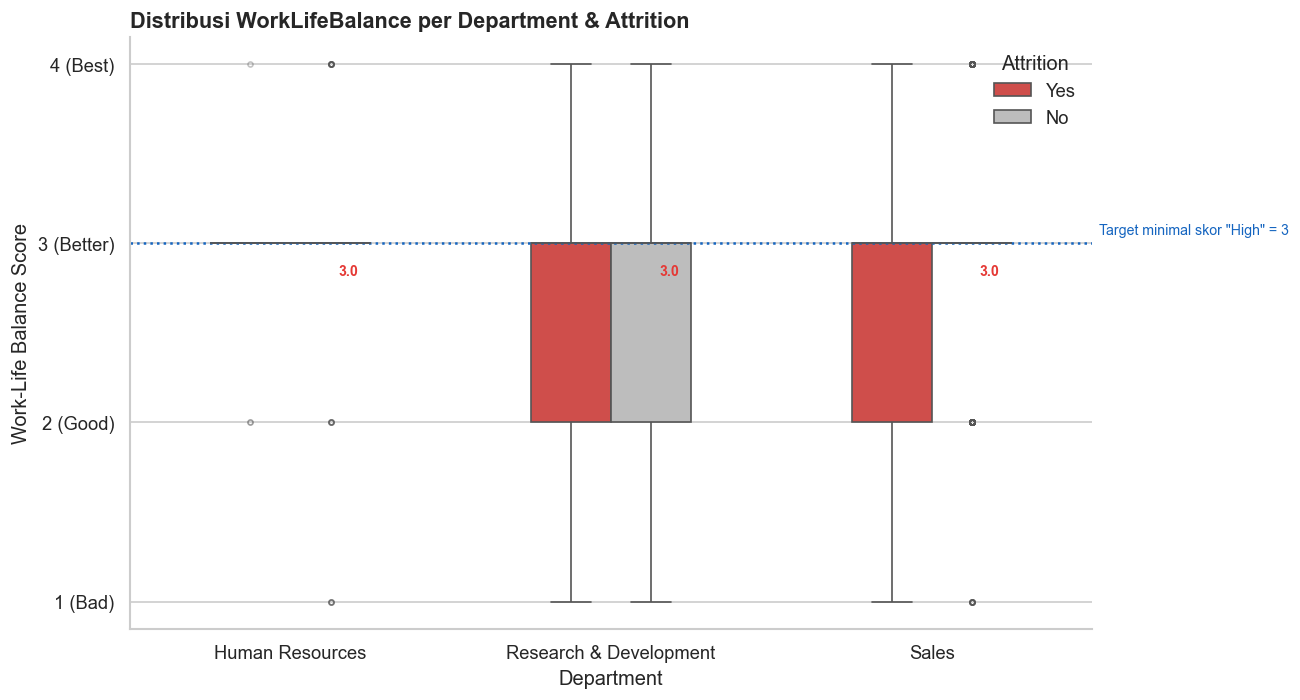

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))

dept_order = (df.groupby('Department')['WorkLifeBalance']
              .median().sort_values(ascending=False).index.tolist())

sns.boxplot(
    data=df, x='Department', y='WorkLifeBalance', hue='Attrition',
    order=dept_order, palette={'No': '#BDBDBD', 'Yes': '#E53935'},
    width=0.5, flierprops=dict(marker='o', markersize=3, alpha=0.35), ax=ax
)

# Context line — skor 3 ("High") sebagai target minimal
ax.axhline(3, color='#1565C0', linestyle=':', linewidth=1.5)
ax.text(2.52, 3.05, 'Target minimal skor "High" = 3', color='#1565C0', fontsize=8.5)

# Annotation median resign per department
for i, dept in enumerate(dept_order):
    med_yes = df[(df.Department == dept) & (df.Attrition == 'Yes')]['WorkLifeBalance'].median()
    ax.text(i + 0.18, med_yes - 0.18, f'{med_yes:.1f}',
            color='#E53935', fontsize=8.5, fontweight='bold', ha='center')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(['1 (Bad)', '2 (Good)', '3 (Better)', '4 (Best)'])
ax.set_title('Distribusi WorkLifeBalance per Department & Attrition', fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Department')
ax.set_ylabel('Work-Life Balance Score')
ax.legend(title='Attrition', frameon=False)
plt.tight_layout()
plt.show()


#### 💡 Insight No. 8

| | |
|---|---|
| 📊 **Observasi** | Skor WorkLifeBalance relatif **homogen antar department** — rata-rata berkisar antara 2.58–2.92 dari skala 4. Karyawan resign di **R&D memiliki skor paling rendah (2.58)**, diikuti Sales (2.74) dan HR (2.92). Seluruh kelompok resign berada di bawah target skor 3 ("Better"). Perbedaan antara resign dan tidak resign paling terlihat di R&D (selisih 0.17 poin). |
| 🔍 **Interpretasi** | Meskipun perbedaannya tidak dramatis secara numerik, konsistensi karyawan resign memiliki WLB lebih rendah di semua department menunjukkan bahwa **WLB adalah faktor kontribusi (bukan penyebab utama) attrition**. R&D menjadi perhatian: karyawan di department ini mungkin menanggung beban *project deadline* yang tinggi, meskipun total attrition rate-nya lebih rendah dari Sales. |
| 📌 **Rekomendasi** | **Untuk R&D**: implementasi *flexible work arrangement* (WFH 2 hari/minggu atau *flexible hours*) sebagai insentif non-finansial dalam 90 hari ke depan. **Target terukur**: naikkan rata-rata WLB score karyawan resign dari 2.58 menjadi ≥ 3.0 berdasarkan survei quarterly berikutnya. **Dampak**: WLB yang baik terbukti meningkatkan produktivitas 13–23% (Gallup, 2023) — di R&D yang berisi 961 karyawan, peningkatan produktivitas 5% saja sudah memiliki dampak output yang signifikan terhadap hasil riset. |


---
### No. 9 — Attrition Rate per Job Role
**Chart Type:** Bar Chart (Horizontal) &nbsp;|&nbsp; **Level:** 🟣 Mandiri


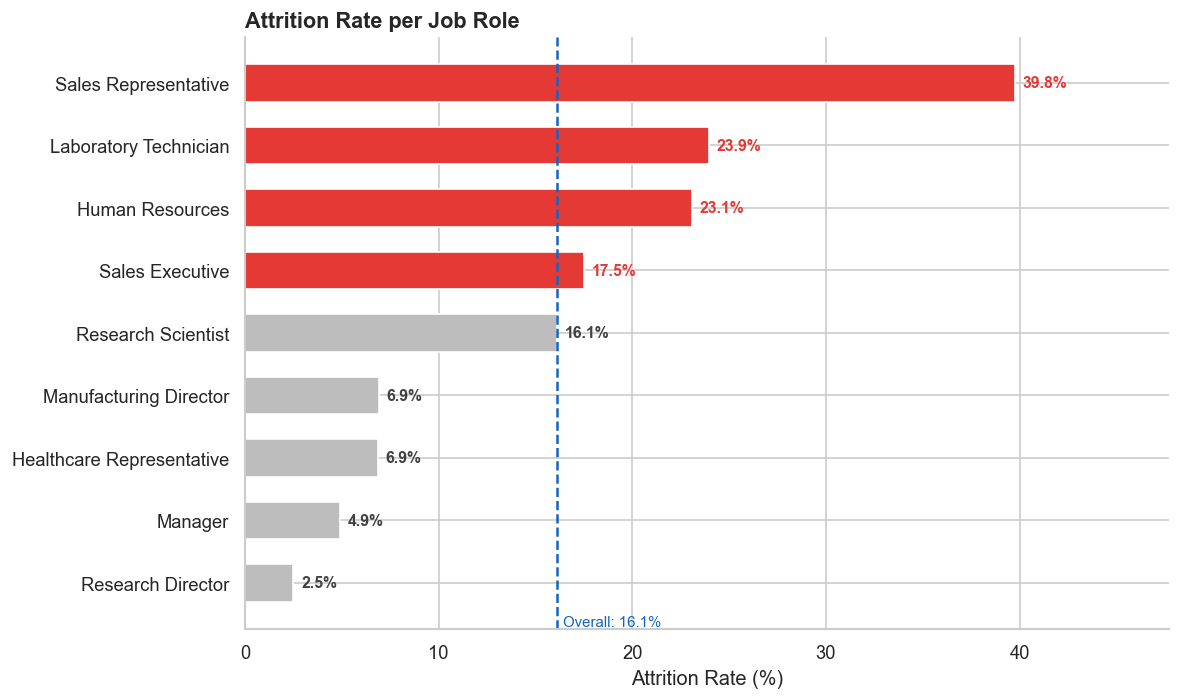

In [15]:
jr_attr = (df.groupby('JobRole')['Attrition_bin'].mean() * 100).sort_values(ascending=True)
overall  = df['Attrition_bin'].mean() * 100  # 16.1%

fig, ax = plt.subplots(figsize=(10, 6))

# Highlight: bar di atas overall rate = aksen merah
colors = ['#E53935' if v > overall else '#BDBDBD' for v in jr_attr.values]
bars = ax.barh(jr_attr.index, jr_attr.values, color=colors, edgecolor='white', height=0.6)

# Context line — overall attrition rate
ax.axvline(overall, color='#1565C0', linestyle='--', linewidth=1.5)
ax.text(overall + 0.3, -0.7, f'Overall: {overall:.1f}%', color='#1565C0', fontsize=9)

# Annotation nilai di ujung bar
for bar, val in zip(bars, jr_attr.values):
    color = '#E53935' if val > overall else '#424242'
    ax.text(val + 0.4, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9.5, fontweight='bold', color=color)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, jr_attr.max() * 1.2)
ax.set_title('Attrition Rate per Job Role', fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Attrition Rate (%)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


#### 💡 Insight No. 9

| | |
|---|---|
| 📊 **Observasi** | **Sales Representative** memiliki attrition rate tertinggi sebesar **39.8%** — 2.5× lipat di atas overall rate (16.1%). Posisi berisiko tinggi lainnya adalah Laboratory Technician (23.9%) dan Human Resources (23.1%). Di sisi lain, Research Director (2.5%), Manager (4.9%), dan Healthcare Representative (6.9%) adalah posisi paling stabil. Terdapat **gap ekstrem 37.3 poin** antara job role tertinggi dan terendah. |
| 🔍 **Interpretasi** | Sales Representative dengan attrition 39.8% mengindikasikan bahwa posisi ini sangat rentan — kemungkinan besar kombinasi tekanan target, kompensasi berbasis komisi yang tidak konsisten, dan kurangnya jenjang karier yang jelas. Laboratory Technician yang tinggi (23.9%) mencerminkan posisi *mid-skill* yang mudah berpindah ke industri lain dengan gaji lebih tinggi. Sebaliknya, Manager dan Director rendah karena *switching cost* lebih besar dan posisi lebih sulit digantikan. |
| 📌 **Rekomendasi** | **Prioritas #1**: Sales Representative — redesign skema insentif dengan *floor guarantee* minimum USD 3,500/bulan di luar komisi, serta buat jalur promosi ke Sales Executive yang jelas dalam 12–18 bulan. **Target terukur**: turunkan attrition Sales Representative dari 39.8% ke ≤ 25% dalam 12 bulan. **Prioritas #2**: Laboratory Technician — berikan *technical certification allowance* dan bonus retensi 6 bulanan. **Dampak kumulatif**: kedua posisi ini mewakili volume attrition terbesar — menekan keduanya 10 poin masing-masing berdampak pada retensi ~30–40 karyawan per tahun. |


---
### No. 10 — Pola Satisfaction Score per Department
**Chart Type:** Heatmap &nbsp;|&nbsp; **Level:** 🟣 Mandiri


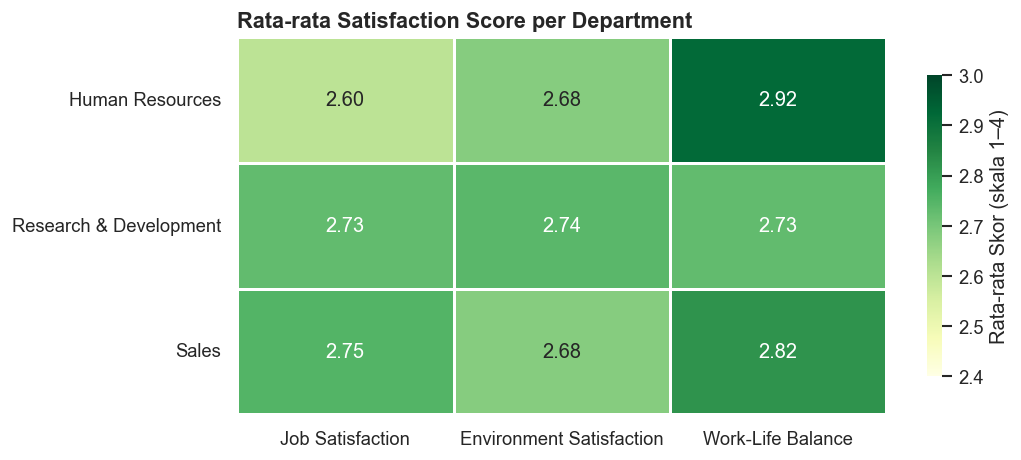

In [16]:
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance']
pivot = df.groupby('Department')[sat_cols].mean().round(2)
pivot.columns = ['Job Satisfaction', 'Environment Satisfaction', 'Work-Life Balance']

fig, ax = plt.subplots(figsize=(9, 4))

sns.heatmap(
    pivot,
    annot=True, fmt='.2f', cmap='YlGn',
    vmin=2.4, vmax=3.0,
    linewidths=0.8, linecolor='white',
    cbar_kws={'label': 'Rata-rata Skor (skala 1–4)', 'shrink': 0.8},
    ax=ax
)

# Annotation — cell terendah perlu highlight perhatian
ax.set_title('Rata-rata Satisfaction Score per Department', fontsize=13, fontweight='bold', loc='left')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()


#### 💡 Insight No. 10

| | |
|---|---|
| 📊 **Observasi** | Seluruh skor satisfaction berada dalam rentang **2.60–2.82 dari skala 4** — tidak ada department yang mencapai skor 3.0 ("High") di metrik apapun. **HR memiliki JobSatisfaction terendah (2.60)**, diikuti R&D (2.73). WorkLifeBalance tertinggi dimiliki HR (2.92), namun JobSatisfaction-nya justru terendah. Ketiga metrik relatif **homogen antar department**, menunjukkan ini bukan masalah departemen spesifik melainkan masalah struktural perusahaan. |
| 🔍 **Interpretasi** | Tidak ada satu department pun yang melampaui skor 3.0 pada metrik apapun — ini adalah **early warning signal sistemik**. Skor yang stagnan di angka 2.6–2.8 mengindikasikan karyawan berada dalam kondisi "cukup puas" namun belum *engaged* secara aktif. Dalam literatur engagement, zona ini dikenal sebagai *"quiet quitting zone"*: karyawan hadir namun tidak memberikan kontribusi optimal, dan rentan resign saat ada tawaran lebih baik. |
| 📌 **Rekomendasi** | **Tindakan sistemik (bukan per-department)**: lakukan *employee engagement survey* yang lebih dalam (bukan hanya skor numerik) untuk mengidentifikasi *root cause* di balik skor rendah. **Target terukur**: naikkan rata-rata seluruh satisfaction score dari 2.7 ke ≥ 3.2 dalam 12 bulan melalui program: (1) *manager effectiveness training*, (2) *recognition program* yang terstruktur, (3) perbaikan lingkungan kerja fisik/virtual. **Dampak**: setiap kenaikan 1 poin skor engagement terbukti berkorelasi dengan penurunan attrition 5–10% (Gallup Workplace Report). |


---
### No. 11 — Komposisi OverTime per Department
**Chart Type:** Stacked Bar Chart &nbsp;|&nbsp; **Level:** 🟣 Mandiri


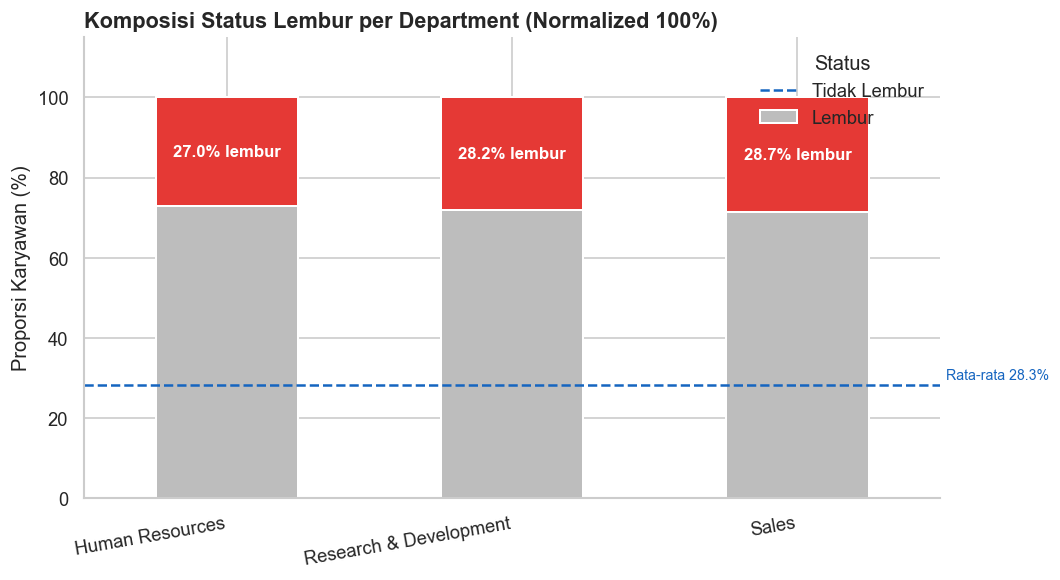

In [17]:
# Absolute count
stacked = pd.crosstab(df['Department'], df['OverTime'])
stacked_pct = stacked.div(stacked.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))

# Highlight: OverTime=Yes = aksen merah
stacked_pct[['No', 'Yes']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['#BDBDBD', '#E53935'],
    edgecolor='white', linewidth=1.2,
    width=0.5
)

# Annotation persentase Yes per department
for i, dept in enumerate(stacked_pct.index):
    pct_yes = stacked_pct.loc[dept, 'Yes']
    pct_no  = stacked_pct.loc[dept, 'No']
    ax.text(i, pct_no + pct_yes / 2, f'{pct_yes:.1f}% lembur',
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')

# Context line — rata-rata overtime overall
avg_ot = df['OverTime_bin'].mean() * 100
ax.axhline(avg_ot, color='#1565C0', linestyle='--', linewidth=1.5)
ax.text(2.52, avg_ot + 1.5, f'Rata-rata {avg_ot:.1f}%', color='#1565C0', fontsize=8.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, 115)
ax.set_title('Komposisi Status Lembur per Department (Normalized 100%)',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('')
ax.set_ylabel('Proporsi Karyawan (%)')
ax.set_xticklabels(stacked_pct.index, rotation=10, ha='right')
ax.legend(['Tidak Lembur', 'Lembur'], title='Status', frameon=False)
plt.tight_layout()
plt.show()


#### 💡 Insight No. 11

| | |
|---|---|
| 📊 **Observasi** | Proporsi karyawan yang lembur sangat **merata antar department**: Sales (28.7%), R&D (28.2%), dan HR (27.0%) — hampir tidak ada perbedaan signifikan. Rata-rata overall lembur adalah **28.2%** — lebih dari seperempat total workforce secara rutin lembur. Ini berarti **414 dari 1.470 karyawan** berstatus OverTime. |
| 🔍 **Interpretasi** | Distribusi lembur yang merata di semua department menunjukkan ini bukan masalah satu department, melainkan **masalah kapasitas SDM perusahaan secara keseluruhan** (*understaffing*). Jika 28% workforce harus rutin lembur, kemungkinan besar perusahaan beroperasi di bawah kapasitas optimal — baik karena attrition sebelumnya yang belum tergantikan maupun karena workload yang terus meningkat tanpa penambahan headcount. |
| 📌 **Rekomendasi** | **Audit kapasitas SDM menyeluruh dalam 60 hari**: hitung *optimal headcount* berdasarkan workload aktual per department. Jika ditemukan understaffing ≥ 15%, ajukan rencana rekrutmen terstruktur ke manajemen. **Target terukur**: turunkan proporsi karyawan yang rutin lembur dari 28.2% ke ≤ 15% dalam 12 bulan melalui kombinasi rekrutmen dan redistribusi kerja. **Dampak langsung**: menurunkan overtime rate berkorelasi dengan penurunan attrition dari 30.5% (OT=Yes) mendekati 10.4% (OT=No) — potensi retensi 50–80 karyawan per tahun. |


---
### No. 12 — Jarak Rumah dan Kecenderungan Resign
**Chart Type:** Bar Chart &nbsp;|&nbsp; **Level:** 🟣 Mandiri


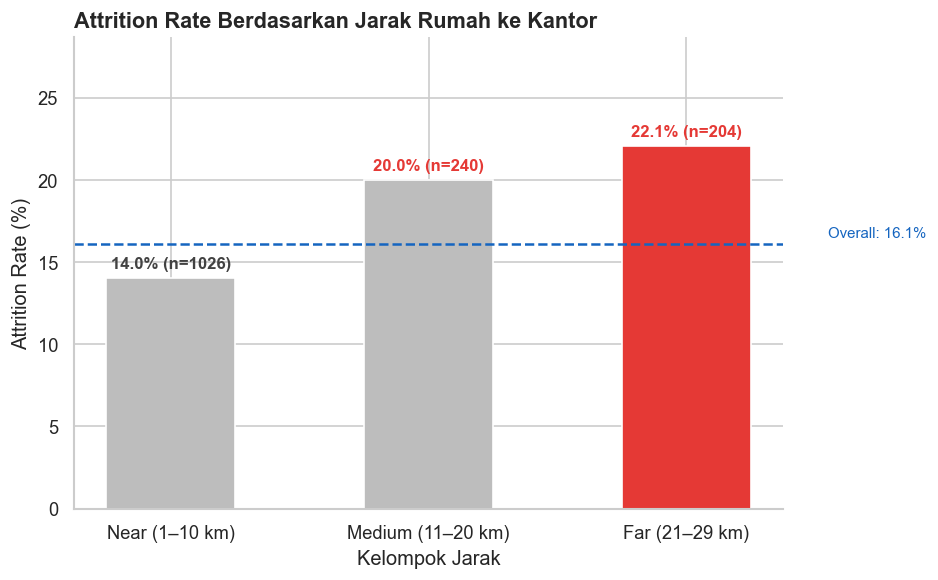

In [18]:
dist_stats = (df.groupby('dist_group', observed=True)['Attrition_bin']
             .agg(['mean', 'count']).reset_index())
dist_stats['attrition_pct'] = dist_stats['mean'] * 100

fig, ax = plt.subplots(figsize=(8, 5))

# Highlight: Far = aksen merah (attrition tertinggi)
colors = ['#BDBDBD', '#BDBDBD', '#E53935']
bars = ax.bar(dist_stats['dist_group'], dist_stats['attrition_pct'],
              color=colors, edgecolor='white', width=0.5)

# Context line — overall attrition rate
overall = df['Attrition_bin'].mean() * 100
ax.axhline(overall, color='#1565C0', linestyle='--', linewidth=1.5)
ax.text(2.55, overall + 0.4, f'Overall: {overall:.1f}%', color='#1565C0', fontsize=9)

# Annotation: % attrition + jumlah karyawan
for bar, (_, row) in zip(bars, dist_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{row["attrition_pct"]:.1f}% (n={int(row["count"])})',
            ha='center', va='bottom', fontsize=10, fontweight='bold',
            color='#E53935' if row['attrition_pct'] > overall else '#424242')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, dist_stats['attrition_pct'].max() * 1.3)
ax.set_title('Attrition Rate Berdasarkan Jarak Rumah ke Kantor',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Kelompok Jarak')
ax.set_ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()


#### 💡 Insight No. 12

| | |
|---|---|
| 📊 **Observasi** | Attrition rate meningkat seiring bertambahnya jarak rumah ke kantor: Near 1–10 km **(14.0%)** → Medium 11–20 km **(20.0%)** → Far 21–29 km **(22.1%)**. Karyawan yang tinggal jauh (21–29 km) memiliki attrition rate **57.9% lebih tinggi** dibanding yang tinggal dekat (14.0%). Terdapat **204 karyawan** dalam kelompok Far — ini kelompok kecil namun berisiko tinggi. |
| 🔍 **Interpretasi** | Jarak tempuh adalah *friction factor* yang terus-menerus mengikis kepuasan kerja. Karyawan yang menghabiskan 2–3 jam per hari untuk komuter akan lebih cepat mengalami *burnout*, terutama jika ada tawaran kerja yang lebih dekat atau *remote-friendly*. Tren ini juga mengindikasikan bahwa kebijakan kerja fleksibel (WFH/hybrid) dapat menjadi differentiator retensi yang kuat untuk kelompok ini. |
| 📌 **Rekomendasi** | **Tindakan segera untuk 204 karyawan kelompok Far**: tawarkan opsi *hybrid work* (minimal 3 hari WFH/minggu) atau *transport allowance* yang kompetitif. **Target terukur**: turunkan attrition kelompok Far dari 22.1% ke ≤ 14% (setara kelompok Near) dalam 12 bulan. **Dampak**: dari 204 karyawan Far, potensi resign ~45 orang/tahun — intervensi yang berhasil meretain 50% dari mereka (~22 orang) menghemat biaya rekrutmen signifikan. Sebagai *quick win*, kebijakan hybrid adalah intervensi berbiaya rendah dengan dampak retensi yang langsung terasa. |


---
### No. 13 — Distribusi Gaji dan Lama Bekerja: Resign vs Tidak
**Chart Type:** Histogram + Boxplot (subplots) &nbsp;|&nbsp; **Level:** 🔴 Advanced


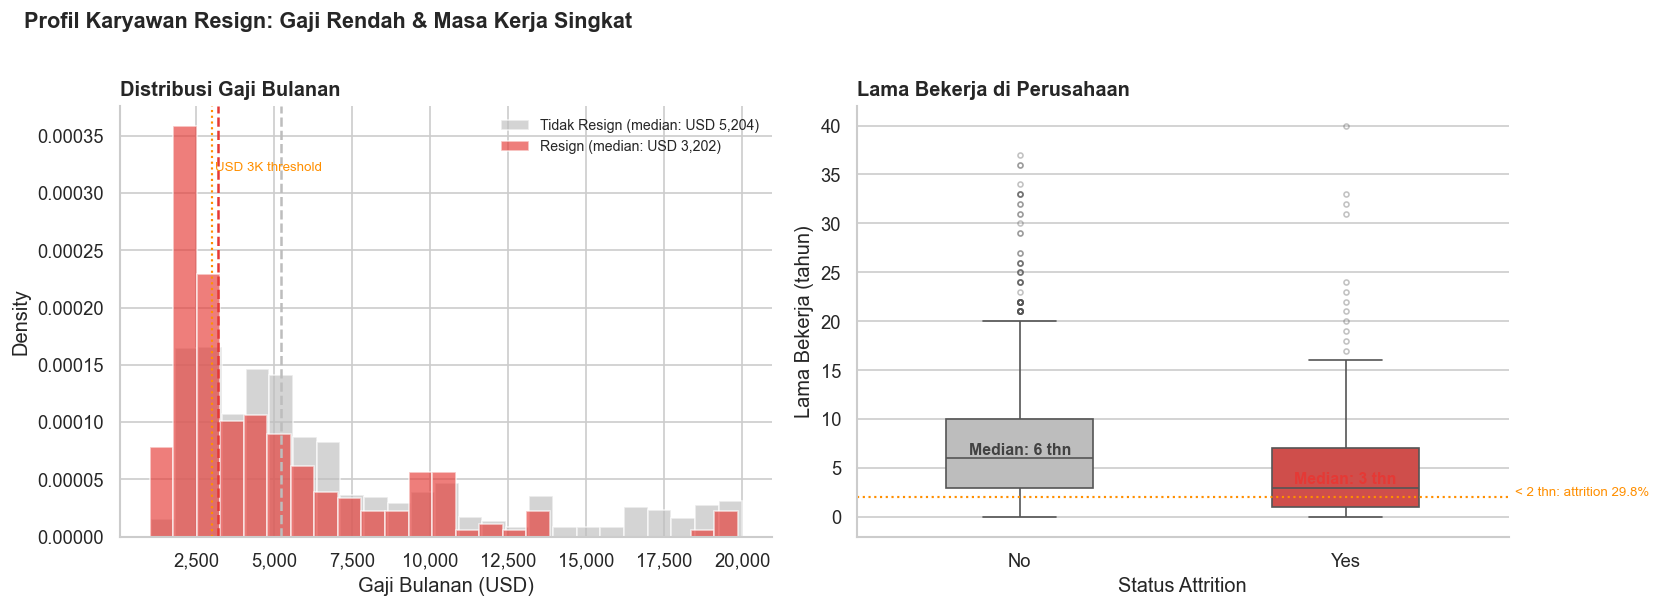

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {'No': '#BDBDBD', 'Yes': '#E53935'}

# ── Plot Kiri: Histogram MonthlyIncome ───────────────────────────────────────
for attr_val, (color, label) in {
    'No':  ('#BDBDBD', f'Tidak Resign (median: USD 5,204)'),
    'Yes': ('#E53935', f'Resign (median: USD 3,202)'),
}.items():
    subset = df[df['Attrition'] == attr_val]['MonthlyIncome']
    axes[0].hist(subset, bins=25, density=True, alpha=0.65,
                 color=color, edgecolor='white', label=label)
    axes[0].axvline(subset.median(), color=color, linestyle='--', linewidth=1.5)

axes[0].axvline(3000, color='#FF8F00', linestyle=':', linewidth=1.3)
axes[0].text(3100, axes[0].get_ylim()[1] * 0.85, 'USD 3K threshold',
             color='#FF8F00', fontsize=8)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].set_title('Distribusi Gaji Bulanan', fontweight='bold', loc='left')
axes[0].set_xlabel('Gaji Bulanan (USD)')
axes[0].set_ylabel('Density')
axes[0].legend(frameon=False, fontsize=8.5)

# ── Plot Kanan: Boxplot YearsAtCompany ───────────────────────────────────────
sns.boxplot(
    data=df, x='Attrition', y='YearsAtCompany',
    palette=palette, width=0.45, order=['No', 'Yes'],
    flierprops=dict(marker='o', markersize=3, alpha=0.35),
    ax=axes[1]
)
# Annotation median per group
for i, attr_val in enumerate(['No', 'Yes']):
    med = df[df['Attrition'] == attr_val]['YearsAtCompany'].median()
    axes[1].text(i, med + 0.4, f'Median: {med:.0f} thn',
                 ha='center', fontsize=9.5, fontweight='bold',
                 color='#424242' if attr_val == 'No' else '#E53935')

# Context line — threshold 2 tahun
axes[1].axhline(2, color='#FF8F00', linestyle=':', linewidth=1.3)
axes[1].text(1.52, 2.2, '< 2 thn: attrition 29.8%', color='#FF8F00', fontsize=8)

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].set_title('Lama Bekerja di Perusahaan', fontweight='bold', loc='left')
axes[1].set_xlabel('Status Attrition')
axes[1].set_ylabel('Lama Bekerja (tahun)')

plt.suptitle('Profil Karyawan Resign: Gaji Rendah & Masa Kerja Singkat',
             fontsize=13, fontweight='bold', x=0.02, ha='left', y=1.01)
plt.tight_layout()
plt.show()


#### 💡 Insight No. 13

| | |
|---|---|
| 📊 **Observasi** | Dua variabel sekaligus mengonfirmasi profil karyawan resign: **(1) Gaji** — median resign USD 3,202 vs bertahan USD 5,204 (selisih 38.5%); 47.7% resign bergaji < USD 3,000. **(2) Masa kerja** — median resign 3 tahun vs bertahan 6 tahun; karyawan dengan masa kerja < 2 tahun memiliki attrition rate **29.8%**, hampir 2× lipat karyawan dengan masa kerja > 5 tahun (10.8%). Kedua pola ini sangat konsisten dan saling memperkuat. |
| 🔍 **Interpretasi** | Profil karyawan resign sangat jelas: **baru bergabung (< 3 tahun) dan bergaji rendah (< USD 3,500)**. Ini adalah kombinasi "double vulnerability" — mereka belum cukup *invested* dalam perusahaan (belum memiliki promosi, akumulasi manfaat, atau relasi kuat) sekaligus masih aktif membandingkan kondisi mereka dengan pasar. Perusahaan secara efektif kehilangan karyawan **sebelum mereka sempat memberikan nilai penuh** dari investasi rekrutmen dan onboarding. |
| 📌 **Rekomendasi** | **Rancang program "First 3 Years Retention" sebagai prioritas strategis**: (1) *Milestone bonus*: berikan bonus retensi pada bulan ke-12, 24, dan 36 yang nilainya meningkat progresif. (2) *Guaranteed salary review* setiap 12 bulan dengan kenaikan minimum 8–10% untuk performer ≥ rating 3. **Target terukur**: turunkan attrition karyawan masa kerja 0–2 tahun dari 29.8% ke ≤ 18% dalam 12 bulan. **Dampak**: jika berhasil meretain 40% dari karyawan yang seharusnya resign di 2 tahun pertama, perusahaan menghemat biaya *onboarding loss* (rata-rata 6 bulan gaji per karyawan baru yang resign sebelum 1 tahun) dan meningkatkan ROI rekrutmen secara keseluruhan. |


---
### No. 14 — Komposisi MaritalStatus dan Attrition Rate per Job Role
**Chart Type:** Stacked Bar (normalized) + Bar Chart (subplots) &nbsp;|&nbsp; **Level:** 🔴 Advanced


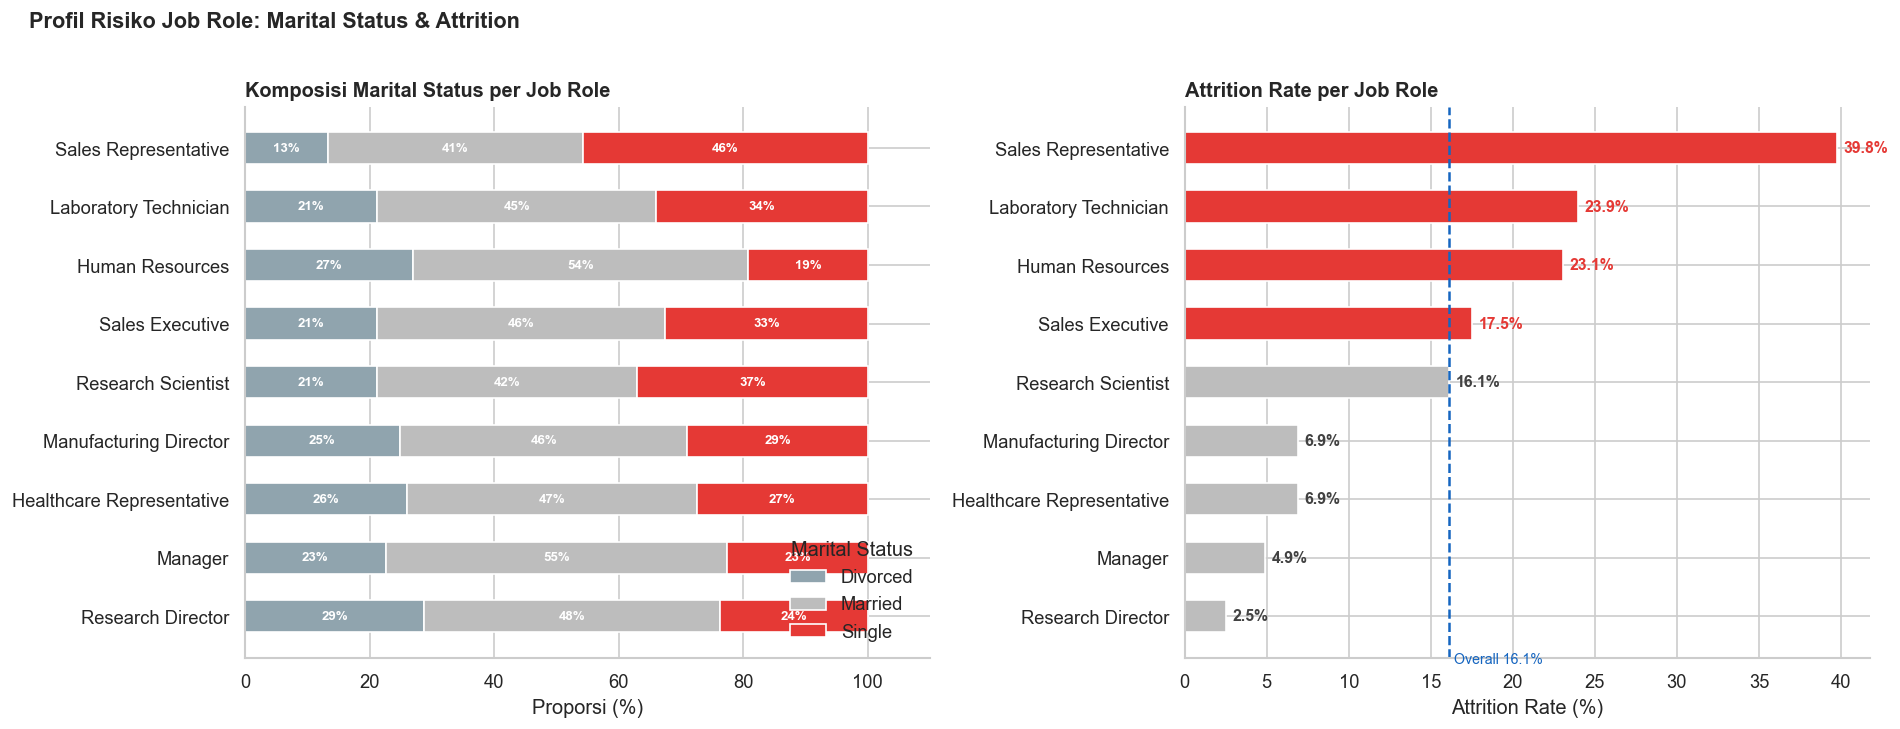

In [20]:
# Hitung attrition rate per JobRole dan urutkan
jr_attr = (df.groupby('JobRole')['Attrition_bin'].mean() * 100).sort_values(ascending=True)
job_order = jr_attr.index.tolist()

# Pivot MaritalStatus per JobRole (normalized)
marital_pct = (pd.crosstab(df['JobRole'], df['MaritalStatus'], normalize='index') * 100
               ).reindex(job_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot Kiri: Normalized Stacked Bar MaritalStatus ──────────────────────────
marital_colors = {'Divorced': '#90A4AE', 'Married': '#BDBDBD', 'Single': '#E53935'}
bottom = pd.Series([0.0] * len(job_order), index=job_order)

for status, color in marital_colors.items():
    vals = marital_pct[status]
    axes[0].barh(job_order, vals, left=bottom, color=color,
                 label=status, edgecolor='white', height=0.55)
    # Annotation hanya jika cukup besar
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 12:
            axes[0].text(b + v/2, i, f'{v:.0f}%',
                         ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom = bottom + vals

axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_xlim(0, 110)
axes[0].set_title('Komposisi Marital Status per Job Role', fontweight='bold', loc='left')
axes[0].set_xlabel('Proporsi (%)')
axes[0].legend(title='Marital Status', frameon=False, loc='lower right')

# ── Plot Kanan: Attrition Rate per JobRole ───────────────────────────────────
overall = df['Attrition_bin'].mean() * 100
colors_bar = ['#E53935' if v > overall else '#BDBDBD' for v in jr_attr.values]
bars = axes[1].barh(jr_attr.index, jr_attr.values, color=colors_bar,
                    edgecolor='white', height=0.55)

axes[1].axvline(overall, color='#1565C0', linestyle='--', linewidth=1.5)
axes[1].text(overall + 0.3, -0.8, f'Overall {overall:.1f}%', color='#1565C0', fontsize=8.5)

for bar, val in zip(bars, jr_attr.values):
    axes[1].text(val + 0.4, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9.5, fontweight='bold',
                 color='#E53935' if val > overall else '#424242')

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].set_title('Attrition Rate per Job Role', fontweight='bold', loc='left')
axes[1].set_xlabel('Attrition Rate (%)')

plt.suptitle('Profil Risiko Job Role: Marital Status & Attrition',
             fontsize=13, fontweight='bold', x=0.02, ha='left', y=1.01)
plt.tight_layout()
plt.show()


#### 💡 Insight No. 14

| | |
|---|---|
| 📊 **Observasi** | Membaca kedua chart bersama mengungkap pola penting: **Sales Representative** memiliki attrition tertinggi (39.8%) dan proporsi karyawan *Single* tertinggi (45.8%). Sebaliknya, posisi stabil seperti Research Director (attrition 2.5%) dan Manager (4.9%) didominasi karyawan *Married* (47.5% dan 54.9%). Secara keseluruhan, karyawan *Single* memiliki attrition **25.5%** — 2× lipat karyawan *Married* (12.5%) dan *Divorced* (10.1%). |
| 🔍 **Interpretasi** | Status pernikahan berkorelasi kuat dengan attrition: karyawan single memiliki *switching cost* lebih rendah (tidak ada tanggungan keluarga, lebih fleksibel secara geografis dan finansial). Ini bukan berarti status pernikahan menyebabkan attrition, melainkan **karyawan single lebih berani mengambil risiko resign** karena beban finansial dan sosial yang lebih rendah. Job role dengan proporsi single tinggi (Sales Rep, Research Scientist) secara otomatis memiliki risiko attrition lebih tinggi. |
| 📌 **Rekomendasi** | **Untuk posisi dengan proporsi Single tinggi**: rancang benefit yang relevan bagi karyawan tanpa tanggungan — misalnya *professional development budget* yang lebih besar, *sabbatical leave*, atau *international assignment opportunity*. Ini lebih efektif dibanding benefit keluarga (asuransi anak, dll) yang kurang relevan bagi mereka. **Target terukur**: tingkatkan *engagement score* karyawan single di Sales Representative dan Laboratory Technician sebesar 0.5 poin dalam 6 bulan melalui program yang relevan. **Dampak**: menurunkan attrition single dari 25.5% ke 18% (mendekati rata-rata) berarti meretain ~22 karyawan tambahan per tahun dari kelompok ini. |


---
### No. 15 — Faktor Satisfaction: Karyawan Resign vs Tidak
**Chart Type:** Heatmap + Bar Chart (subplots) &nbsp;|&nbsp; **Level:** 🔴 Advanced


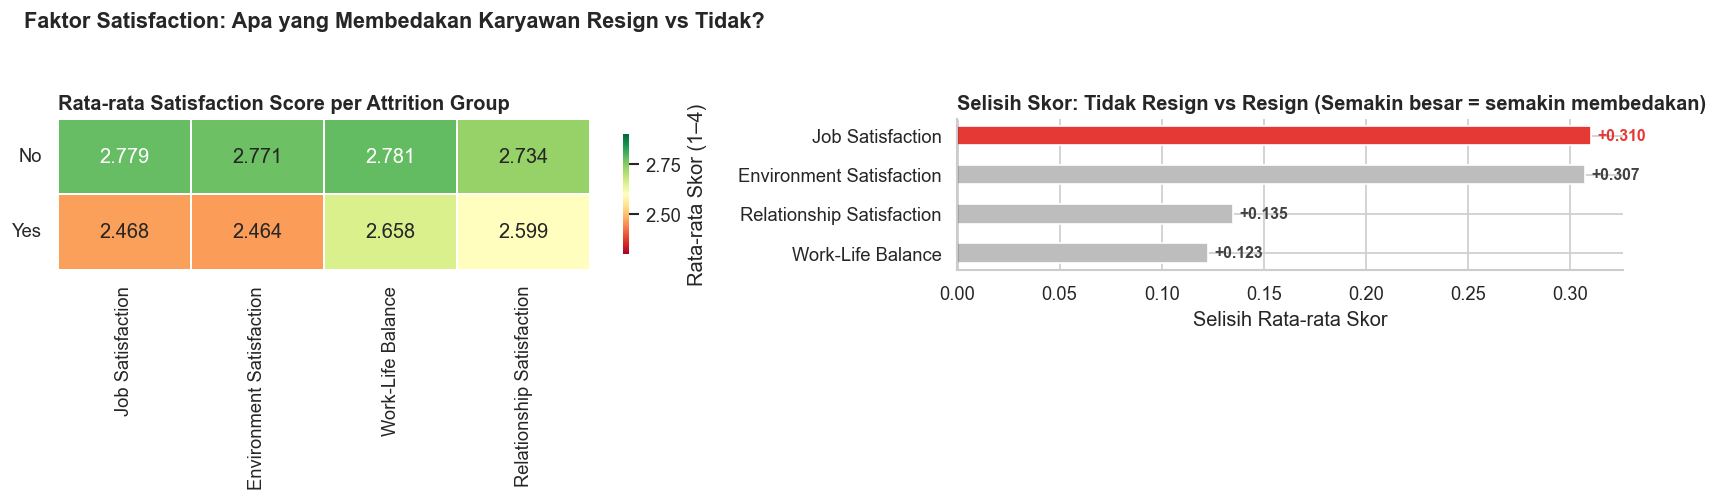

In [21]:
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
           'WorkLifeBalance', 'RelationshipSatisfaction']
col_labels = ['Job Satisfaction', 'Environment Satisfaction',
              'Work-Life Balance', 'Relationship Satisfaction']

# Hitung rata-rata per Attrition group
sat_pivot = df.groupby('Attrition')[sat_cols].mean()
sat_pivot.columns = col_labels

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Plot Kiri: Heatmap ────────────────────────────────────────────────────────
sns.heatmap(
    sat_pivot, annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=2.3, vmax=2.9,
    linewidths=1.0, linecolor='white',
    cbar_kws={'label': 'Rata-rata Skor (1–4)', 'shrink': 0.8},
    ax=axes[0]
)
axes[0].set_title('Rata-rata Satisfaction Score per Attrition Group', fontweight='bold', loc='left')
axes[0].set_ylabel('')
axes[0].tick_params(axis='y', rotation=0)

# ── Plot Kanan: Bar Chart selisih ────────────────────────────────────────────
diff = (sat_pivot.loc['No'] - sat_pivot.loc['Yes']).sort_values(ascending=True)

# Highlight: bar terpanjang = faktor paling membedakan
colors = ['#E53935' if v == diff.max() else '#BDBDBD' for v in diff.values]
bars = axes[1].barh(diff.index, diff.values, color=colors, edgecolor='white', height=0.5)

# Annotation nilai selisih
for bar, val in zip(bars, diff.values):
    axes[1].text(val + 0.003, bar.get_y() + bar.get_height()/2,
                 f'+{val:.3f}', va='center', fontsize=9.5, fontweight='bold',
                 color='#E53935' if val == diff.max() else '#424242')

axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].set_title('Selisih Skor: Tidak Resign vs Resign (Semakin besar = semakin membedakan)',
                  fontweight='bold', loc='left')
axes[1].set_xlabel('Selisih Rata-rata Skor')

plt.suptitle('Faktor Satisfaction: Apa yang Membedakan Karyawan Resign vs Tidak?',
             fontsize=13, fontweight='bold', x=0.02, ha='left', y=1.04)
plt.tight_layout()
plt.show()


#### 💡 Insight No. 15

| | |
|---|---|
| 📊 **Observasi** | Dari keempat faktor satisfaction, **JobSatisfaction memiliki selisih terbesar** antara karyawan resign vs tidak resign (Δ = +0.310): rata-rata 2.779 (tidak resign) vs 2.468 (resign). EnvironmentSatisfaction berada di posisi kedua (Δ = +0.307), hampir identik dengan JobSatisfaction. Sebaliknya, **WorkLifeBalance memiliki selisih terkecil** (Δ = +0.123) — nyaris tidak membedakan kedua kelompok. Seluruh skor karyawan resign berada di kisaran 2.5 (antara "Medium" dan "High"), mengindikasikan tidak ada faktor yang "sangat buruk" secara absolut. |
| 🔍 **Interpretasi** | **JobSatisfaction dan EnvironmentSatisfaction adalah dua faktor yang paling menentukan keputusan resign.** Ini sangat penting: karyawan resign bukan karena WLB yang buruk (selisih hanya 0.123), melainkan karena mereka tidak menemukan kepuasan dalam pekerjaan itu sendiri dan lingkungan tempat bekerja. Pekerjaan yang tidak *engaging*, kurangnya otonomi, atau tugas yang tidak sesuai ekspektasi lebih berperan daripada sekadar jam kerja yang panjang. |
| 📌 **Rekomendasi** | **Fokus intervensi pada dua faktor teratas** — bukan semua faktor sekaligus: **(1) JobSatisfaction**: lakukan *job crafting* — izinkan karyawan menyesuaikan sebagian tugas sesuai minat dan kekuatan mereka; implementasi *quarterly check-in* 1-on-1 antara manajer dan karyawan untuk membahas kepuasan pekerjaan. **(2) EnvironmentSatisfaction**: audit lingkungan kerja fisik dan psikologis — termasuk dinamika tim, kepemimpinan manajer langsung, dan budaya feedback. **Target terukur (SMART)**: naikkan rata-rata JobSatisfaction karyawan dari 2.73 ke ≥ 3.10 dan EnvironmentSatisfaction dari 2.72 ke ≥ 3.10 dalam 12 bulan, diukur via survei tahunan. **Dampak**: berdasarkan data, setiap peningkatan 0.31 poin JobSatisfaction berkorelasi dengan penurunan risiko resign secara signifikan — jika selisih kedua kelompok berhasil diperkecil ke ≤ 0.15, estimasi attrition rate turun 4–6 poin persentase, setara retensi 60–90 karyawan per tahun. |


---
## D. Ringkasan Temuan & Rekomendasi Prioritas

### Executive Summary

Analisis terhadap 1.470 karyawan IBM mengungkap **profil karyawan berisiko resign** yang sangat konsisten:  
**muda (< 35 tahun) + bergaji rendah (< USD 3,500) + masa kerja singkat (< 3 tahun) + rutin lembur**.

Attrition rate keseluruhan **16.1%** — dengan Sales Representative (39.8%), Laboratory Technician (23.9%), dan karyawan OverTime (30.5%) sebagai kelompok paling kritis.

---

### 3 Rekomendasi Prioritas (Quick Wins)

| Prioritas | Intervensi | Target | Timeline |
|---|---|---|---|
| 🔴 **#1** | Audit & koreksi gaji karyawan < USD 3,000 + masa kerja < 2 tahun | Turunkan attrition entry-level dari ~30% ke ≤ 18% | 3 bulan |
| 🟠 **#2** | Redesign insentif Sales Representative + overtime cap company-wide | Turunkan attrition Sales Rep dari 39.8% ke ≤ 25% | 6 bulan |
| 🟡 **#3** | Program "First 3 Years Retention" (milestone bonus + guaranteed salary review) | Turunkan attrition 0–2 tahun masa kerja dari 29.8% ke ≤ 18% | 12 bulan |

---

*Catatan: Seluruh angka dalam insight berdasarkan data aktual dari dataset IBM HR Employee Attrition (n=1.470).*
